In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
telco_df = pd.read_csv('Telco-Customer-Churn.csv')

In [3]:
telco_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
telco_df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [5]:
telco_df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
telco_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
telco_df.isna().sum().sum()

np.int64(0)

In [8]:
telco_df.duplicated().sum()

np.int64(0)

In [9]:
for col in telco_df.columns:
    print(f'{col}: {telco_df[col].nunique()}')

customerID: 7043
gender: 2
SeniorCitizen: 2
Partner: 2
Dependents: 2
tenure: 73
PhoneService: 2
MultipleLines: 3
InternetService: 3
OnlineSecurity: 3
OnlineBackup: 3
DeviceProtection: 3
TechSupport: 3
StreamingTV: 3
StreamingMovies: 3
Contract: 3
PaperlessBilling: 2
PaymentMethod: 4
MonthlyCharges: 1585
TotalCharges: 6531
Churn: 2


In [10]:
for col in telco_df.columns:
    print(f'{col}: {telco_df[col].sort_values().unique()}')

customerID: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: ['No' 'Yes']
Dependents: ['No' 'Yes']
tenure: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72]
PhoneService: ['No' 'Yes']
MultipleLines: ['No' 'No phone service' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'No internet service' 'Yes']
OnlineBackup: ['No' 'No internet service' 'Yes']
DeviceProtection: ['No' 'No internet service' 'Yes']
TechSupport: ['No' 'No internet service' 'Yes']
StreamingTV: ['No' 'No internet service' 'Yes']
StreamingMovies: ['No' 'No internet service' 'Yes']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['No' 'Yes']
PaymentMethod: ['Bank transfer (automatic)' 'Credit card (automatic)' 'Elect

Lets fix the Data types first

the main issue with the Total_charges is that it has some Na values but its like a space like this ' ' so we cant directly convert them to float

In [11]:
telco_df.TotalCharges.sort_values().unique()

array([' ', '100.2', '100.25', ..., '999.45', '999.8', '999.9'],
      dtype=object)

In [12]:
for i in telco_df[telco_df.TotalCharges == ' '].index:
    telco_df.loc[i, 'TotalCharges'] = telco_df.loc[i, 'MonthlyCharges']

In [13]:
telco_df['TotalCharges'] = telco_df.TotalCharges.astype('float')

In [14]:
telco_df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.798992
std,0.368612,24.559481,30.090047,2266.730170
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [15]:
telco_df.describe(include='object').T

,count,unique,top,freq
customerID,7043,7043,3186-AJIEK,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


### Lets start our Eda


our analysis should be focused on Churn and we have to gather information on why are people churning

we have hierarchical columns too lets split them and see if the hierarchy is correct


if phone service is No then Multiple lines cant be yes


In [16]:
no_phone = telco_df[telco_df.PhoneService == "No"]
yes_phone = telco_df[telco_df.PhoneService == "Yes"]

In [17]:
no_phone.MultipleLines.value_counts()

,count
MultipleLines,
No phone service,682


In [18]:
yes_phone.MultipleLines.value_counts()

,count
MultipleLines,
No,3390
Yes,2971


if internet service is no then the services related to internet should be no aswell

In [19]:
no_int = telco_df[telco_df.InternetService == "No"]
yes_int = telco_df[telco_df.InternetService != "No"]

In [20]:
no_int[['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies']].value_counts()

,,,,,,count
OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,
No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,1526


In [21]:
for col in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies']:
       print(yes_int[col].value_counts())

OnlineSecurity
No     3498
Yes    2019
Name: count, dtype: int64
OnlineBackup
No     3088
Yes    2429
Name: count, dtype: int64
DeviceProtection
No     3095
Yes    2422
Name: count, dtype: int64
TechSupport
No     3473
Yes    2044
Name: count, dtype: int64
StreamingTV
No     2810
Yes    2707
Name: count, dtype: int64
StreamingMovies
No     2785
Yes    2732
Name: count, dtype: int64


Perfect Hierarchy

# **Churn** analysis

In [22]:
telco_df.Churn.value_counts(normalize=True)*100

,proportion
Churn,
No,73.463013
Yes,26.536987


almost 27% of customers churned

In [23]:
# lets split the churn and non churn
churn_df = telco_df[telco_df.Churn == 'Yes']
non_churn_df = telco_df[telco_df.Churn == 'No']

In [24]:
churn_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
13,0280-XJGEX,Male,0,No,No,49,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes


In [25]:
non_churn_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No


In [26]:
print(f'Churn: {churn_df.shape[0]}')
print(f'Non Churn: {non_churn_df.shape[0]}')

Churn: 1869
Non Churn: 5174


In [27]:
print('Ratio      Female    Male')
print(f'Churn:     {churn_df.gender.value_counts(normalize=True).values*100}')
print(f'Non Churn: {non_churn_df.gender.value_counts(normalize=True).values*100}')

Ratio      Female    Male
Churn:     [50.24077047 49.75922953]
Non Churn: [50.73444144 49.26555856]


In [28]:
for col in churn_df.columns:
  if churn_df[col].nunique() < 6:
    print('Churn \n')
    print(f'{col}: {churn_df[col].value_counts(normalize=True)}\n')
    print('Non Churn \n')
    print(f'{col}: {non_churn_df[col].value_counts(normalize=True)}\n\n\n')

Churn 

gender: gender
Female    0.502408
Male      0.497592
Name: proportion, dtype: float64

Non Churn 

gender: gender
Male      0.507344
Female    0.492656
Name: proportion, dtype: float64



Churn 

SeniorCitizen: SeniorCitizen
0    0.745318
1    0.254682
Name: proportion, dtype: float64

Non Churn 

SeniorCitizen: SeniorCitizen
0    0.871279
1    0.128721
Name: proportion, dtype: float64



Churn 

Partner: Partner
No     0.642055
Yes    0.357945
Name: proportion, dtype: float64

Non Churn 

Partner: Partner
Yes    0.528218
No     0.471782
Name: proportion, dtype: float64



Churn 

Dependents: Dependents
No     0.825575
Yes    0.174425
Name: proportion, dtype: float64

Non Churn 

Dependents: Dependents
No     0.655199
Yes    0.344801
Name: proportion, dtype: float64



Churn 

PhoneService: PhoneService
Yes    0.909042
No     0.090958
Name: proportion, dtype: float64

Non Churn 

PhoneService: PhoneService
Yes    0.901044
No     0.098956
Name: proportion, dtype: float64



Chur

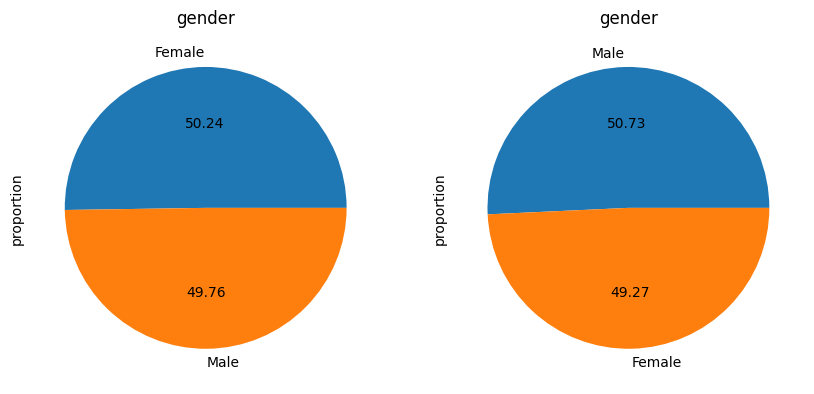

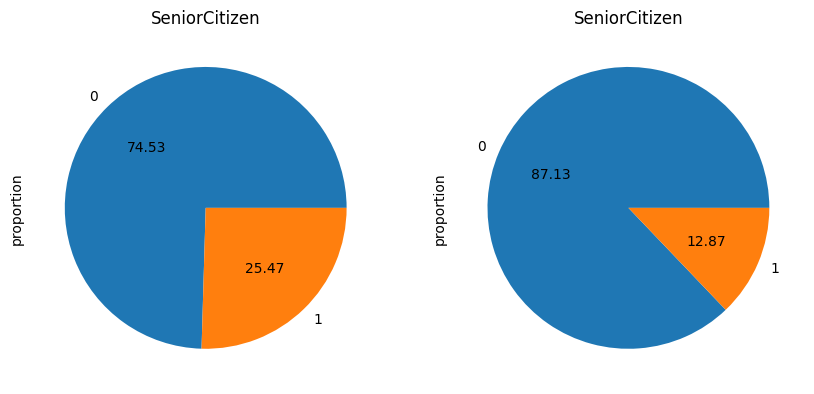

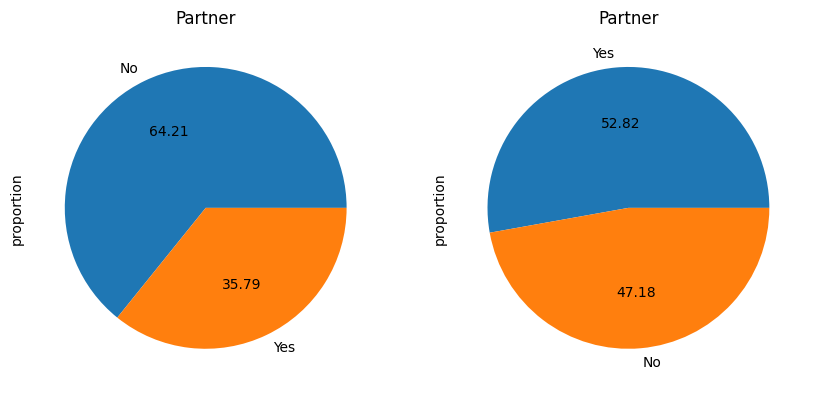

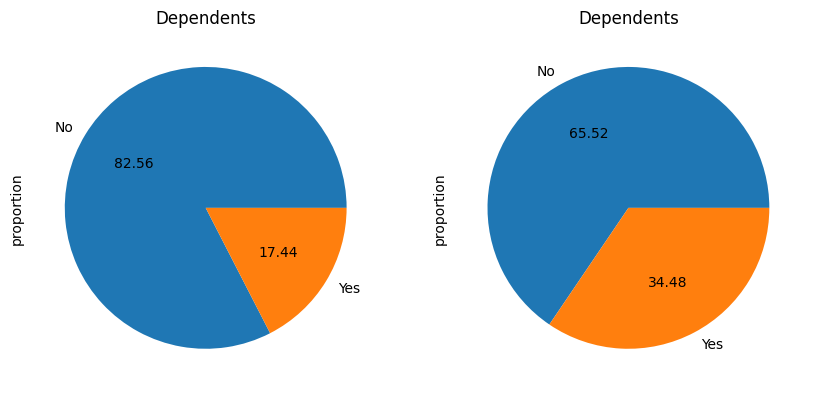

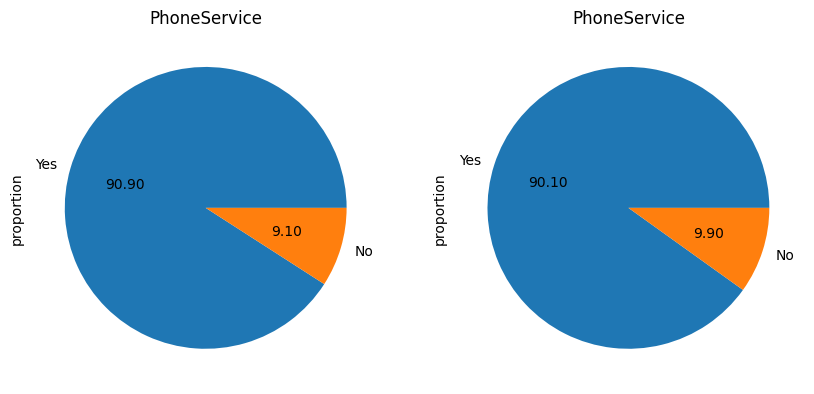

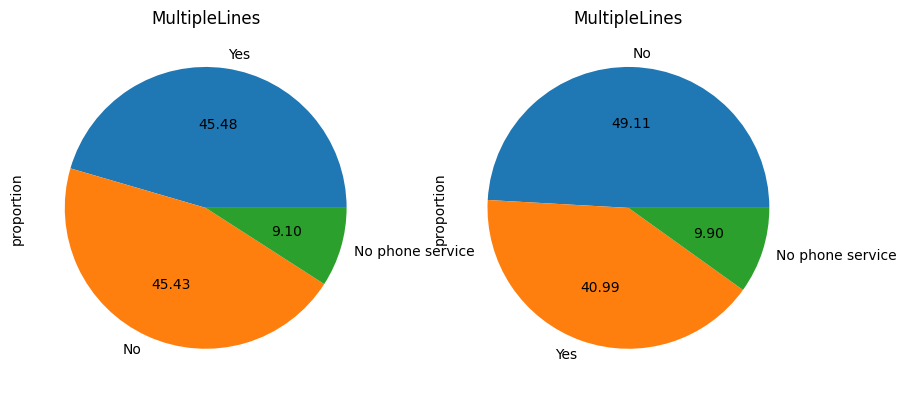

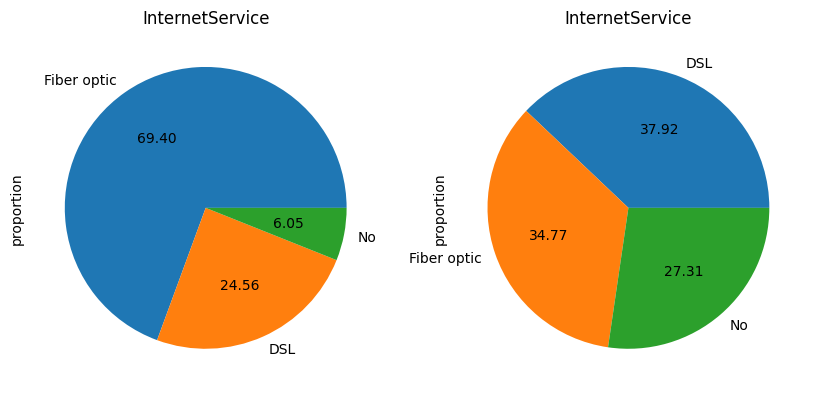

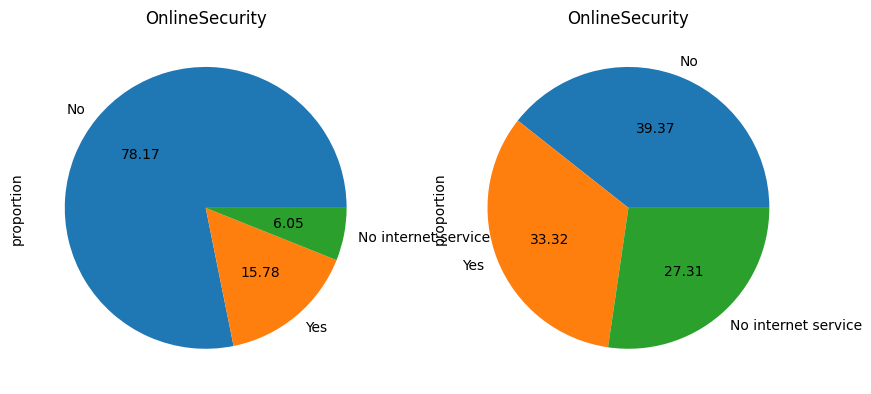

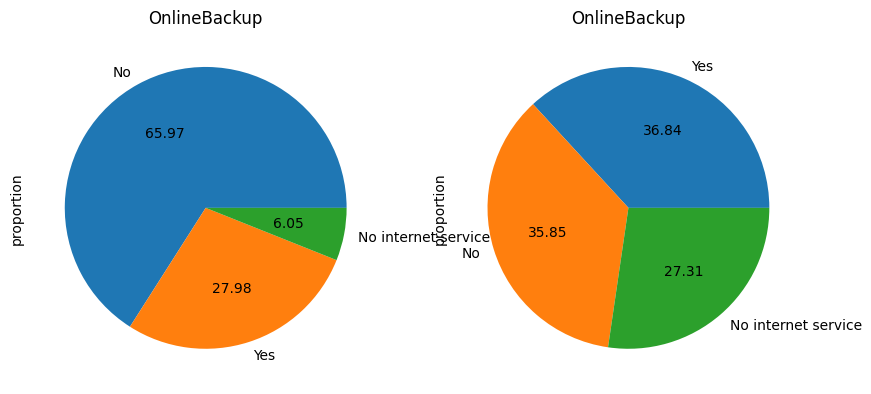

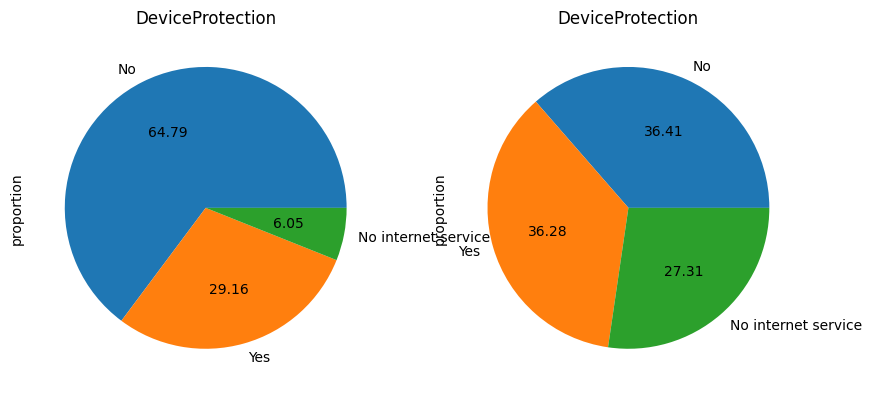

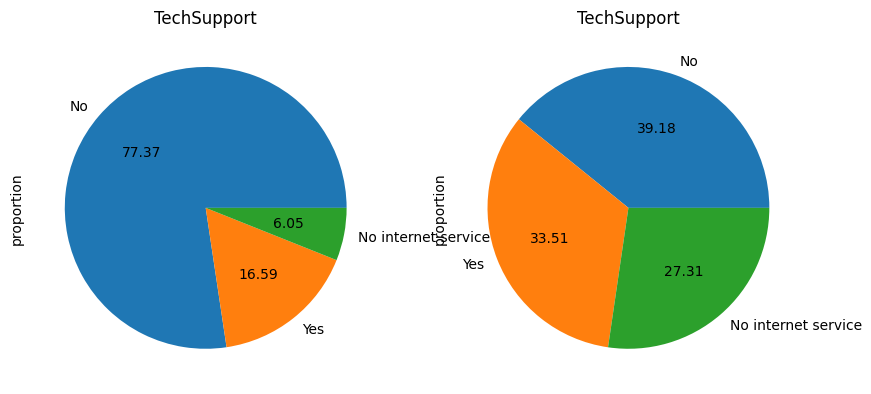

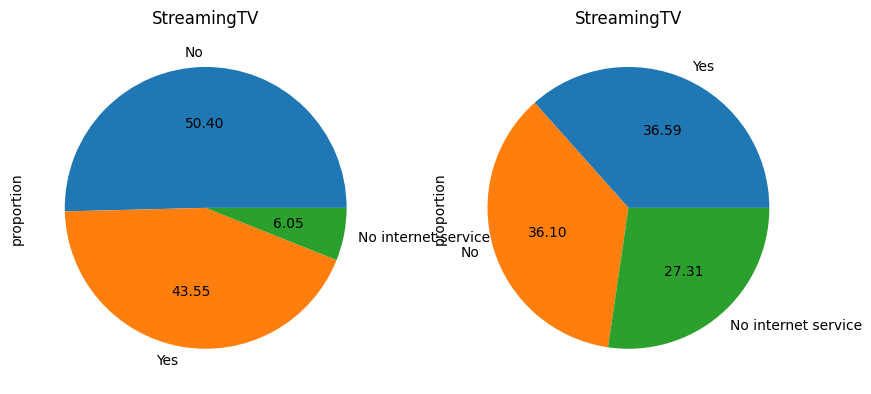

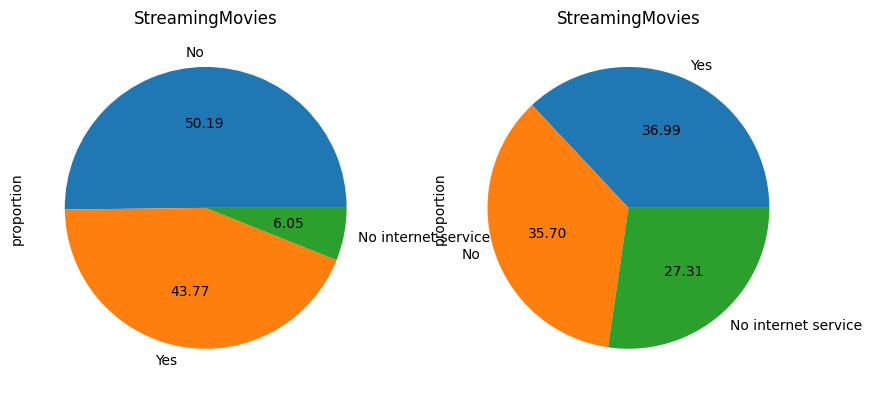

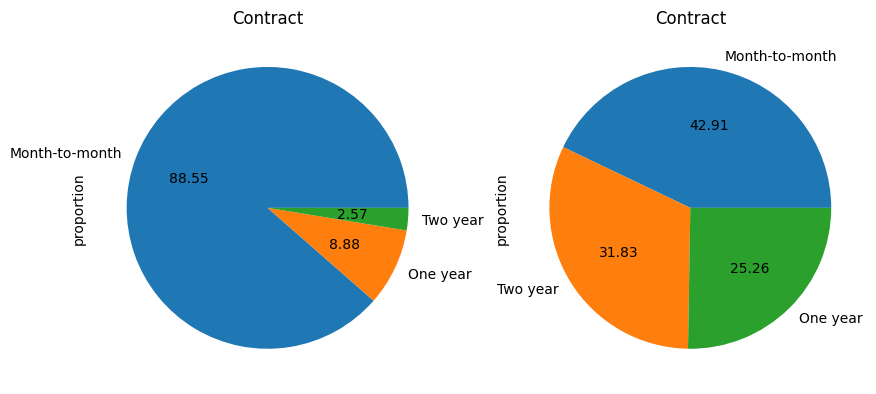

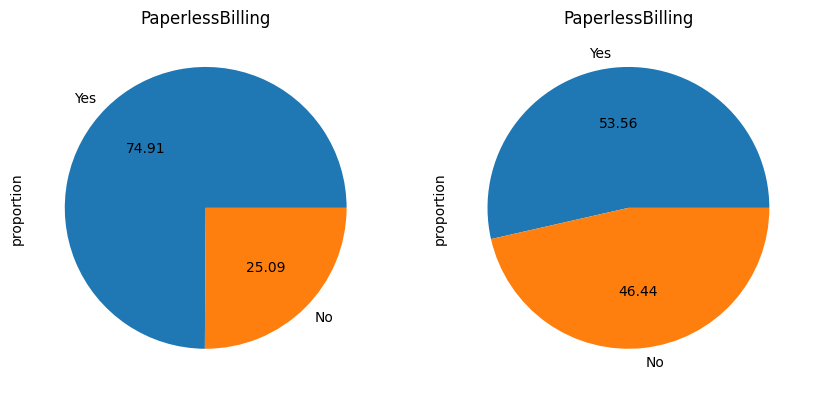

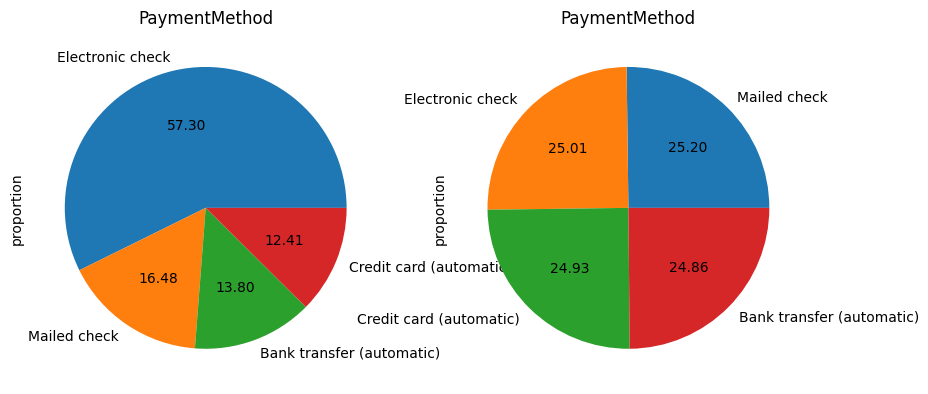

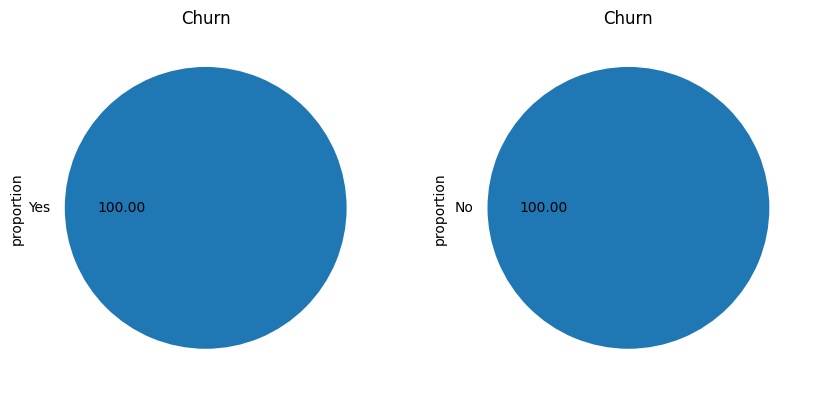

In [29]:
for col in churn_df.columns:

  if churn_df[col].nunique() < 6:
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    churn_df[col].value_counts(normalize=True).plot(kind='pie', autopct='%.2f')
    plt.title(col)
    plt.subplot(1,2,2)
    non_churn_df[col].value_counts(normalize=True).plot(kind='pie', autopct='%.2f')
    plt.title(col)
    plt.show()

values mostlty fluctuated between churn and non churn in senior_citzen, partners, dependents, internet_service,multiple_lines,online securities, online backup,device protection, tech support,streaming tv or movies, contract, paperless billing and payment method

In [30]:
columnss = []
for col in churn_df.columns:
  if churn_df[col].nunique() < 6:
    if churn_df[col].value_counts(normalize=True)[0] > 0.6:
      print('Churn \n')
      print(f'{col}: {churn_df[col].value_counts(normalize=True)}\n')
      print('Non Churn \n')
      print(f'{col}: {non_churn_df[col].value_counts(normalize=True)}\n\n\n')
      columnss.append(col)
print(f"Columns having an effect in Churning are {columnss}")

Churn 

SeniorCitizen: SeniorCitizen
0    0.745318
1    0.254682
Name: proportion, dtype: float64

Non Churn 

SeniorCitizen: SeniorCitizen
0    0.871279
1    0.128721
Name: proportion, dtype: float64



Churn 

Partner: Partner
No     0.642055
Yes    0.357945
Name: proportion, dtype: float64

Non Churn 

Partner: Partner
Yes    0.528218
No     0.471782
Name: proportion, dtype: float64



Churn 

Dependents: Dependents
No     0.825575
Yes    0.174425
Name: proportion, dtype: float64

Non Churn 

Dependents: Dependents
No     0.655199
Yes    0.344801
Name: proportion, dtype: float64



Churn 

PhoneService: PhoneService
Yes    0.909042
No     0.090958
Name: proportion, dtype: float64

Non Churn 

PhoneService: PhoneService
Yes    0.901044
No     0.098956
Name: proportion, dtype: float64



Churn 

InternetService: InternetService
Fiber optic    0.693954
DSL            0.245586
No             0.060460
Name: proportion, dtype: float64

Non Churn 

InternetService: InternetService
DSL     

In [31]:
telco_df.Churn = telco_df.Churn.map({'Yes':1, 'No':0})

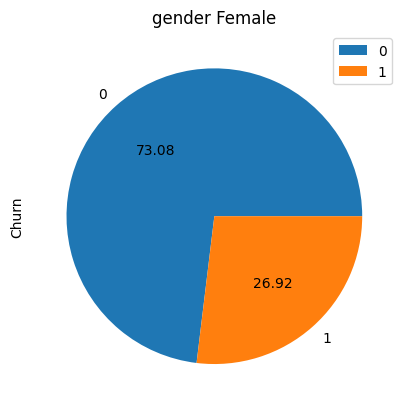

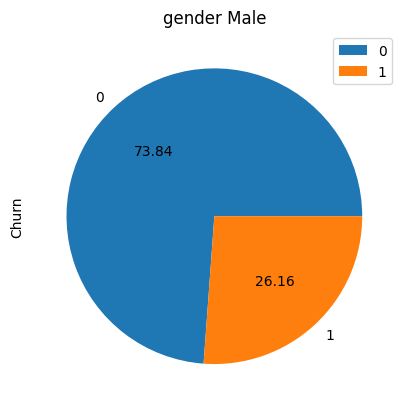

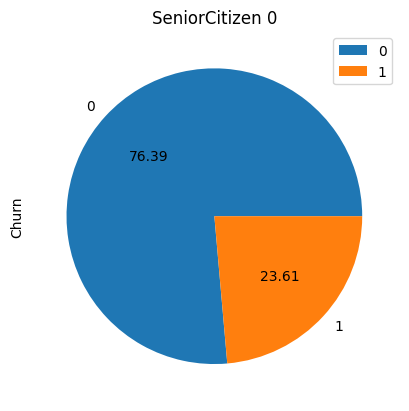

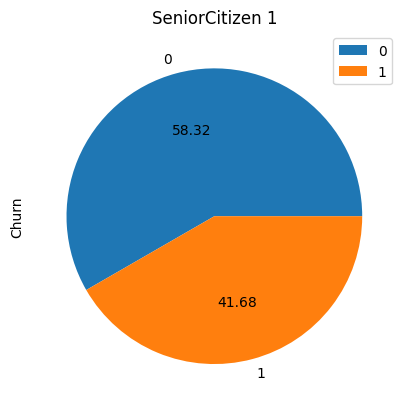

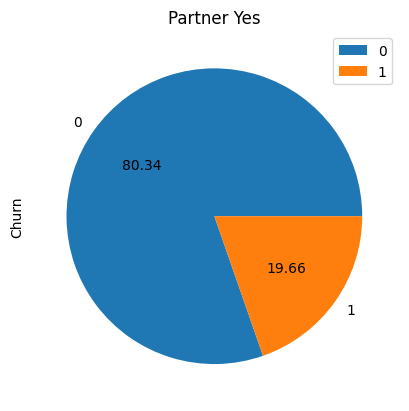

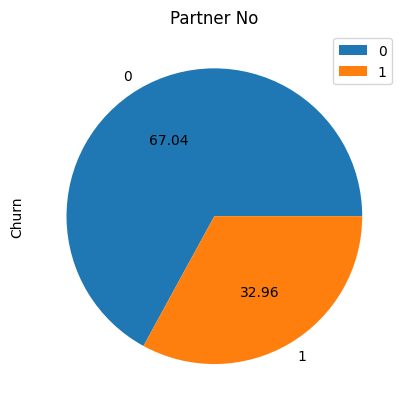

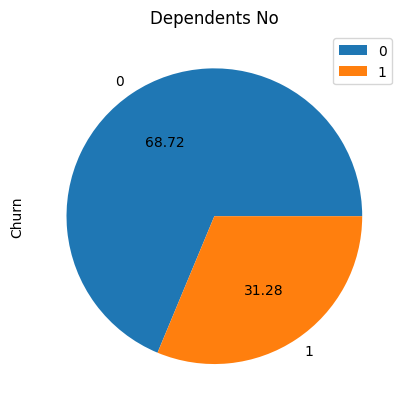

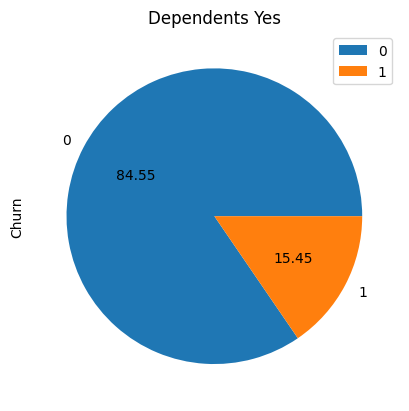

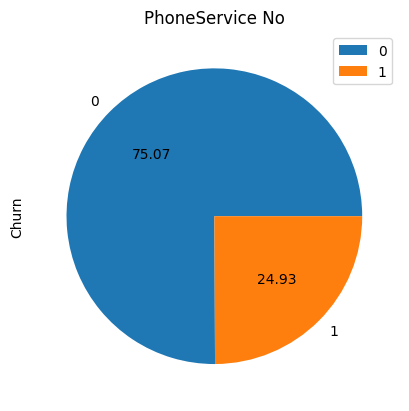

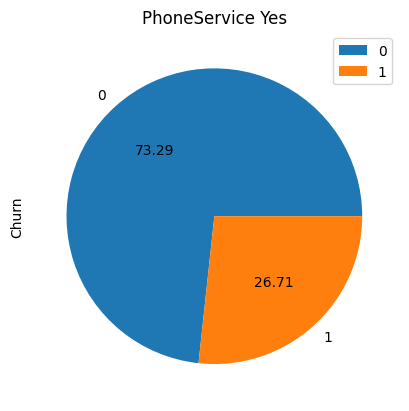

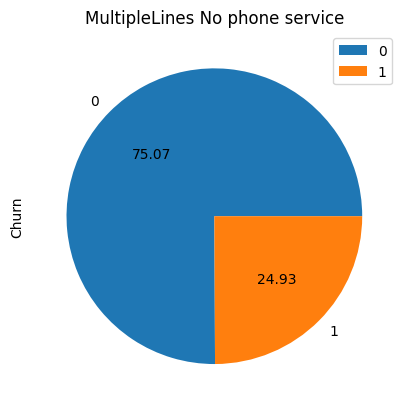

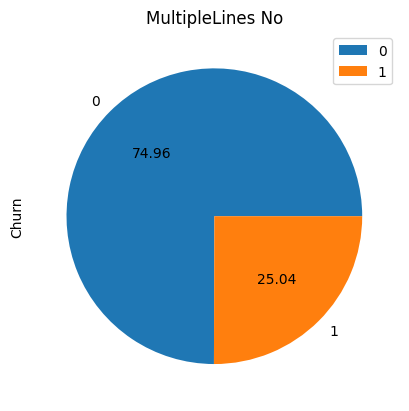

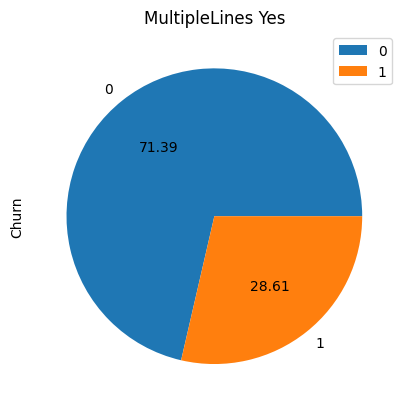

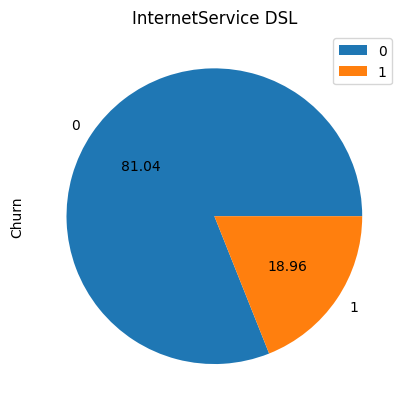

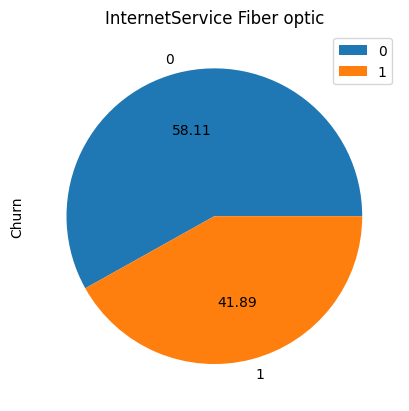

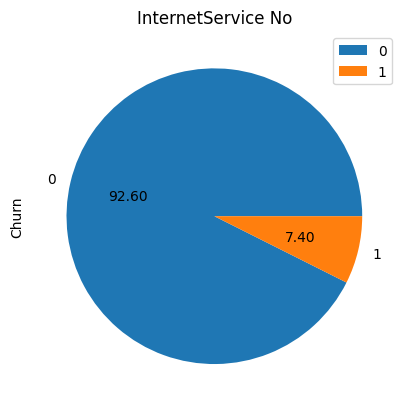

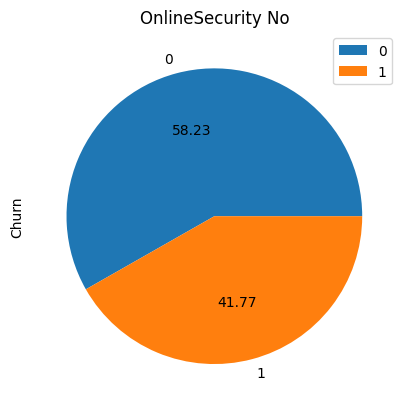

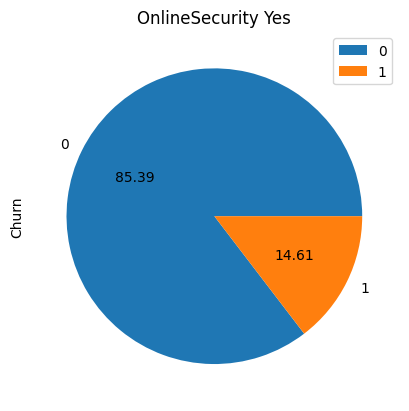

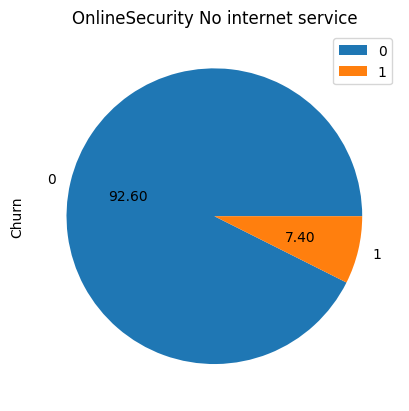

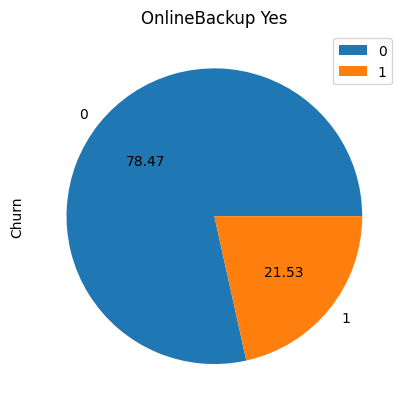

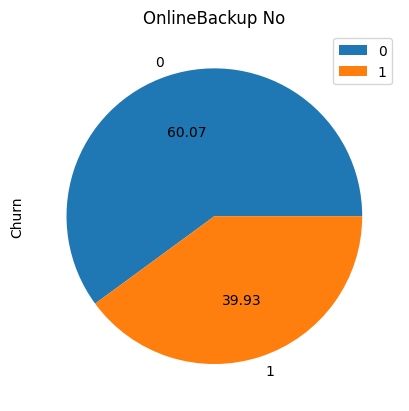

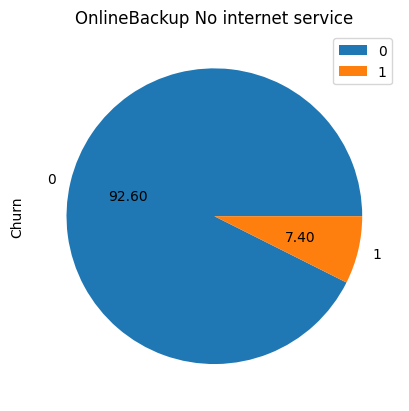

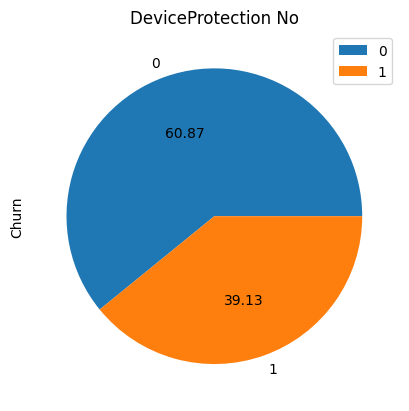

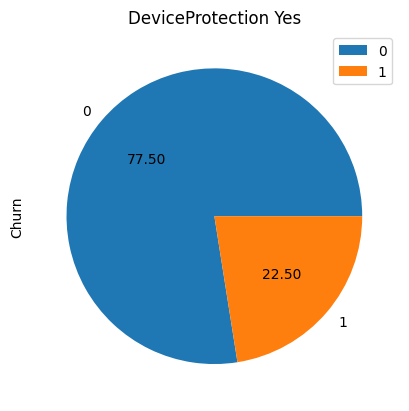

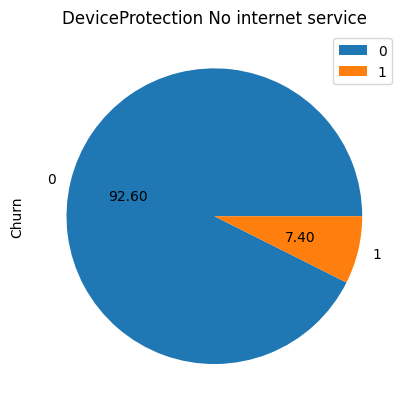

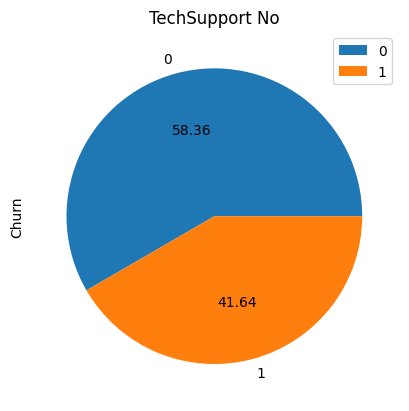

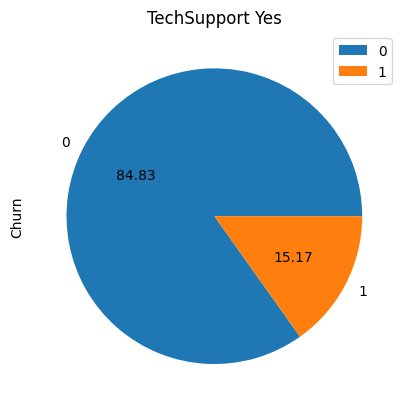

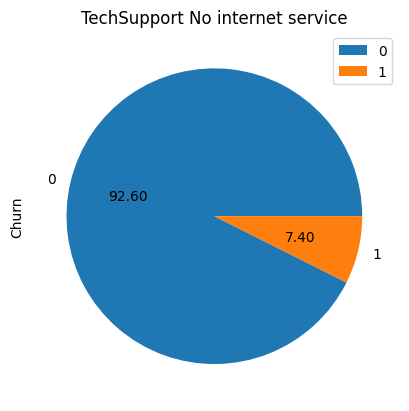

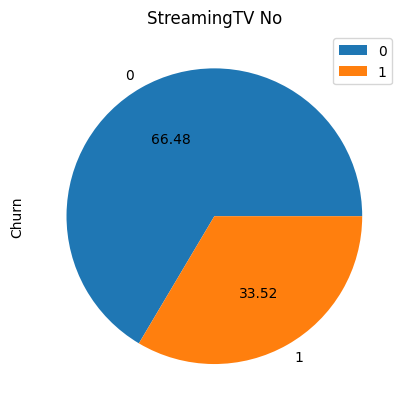

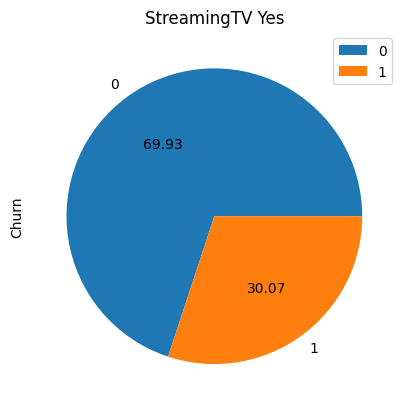

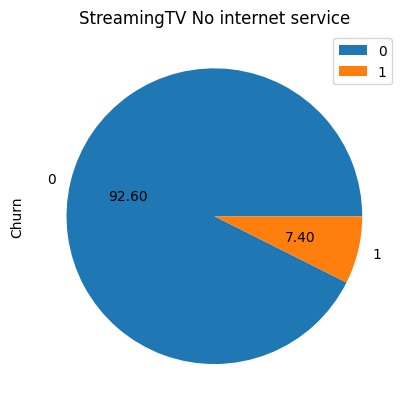

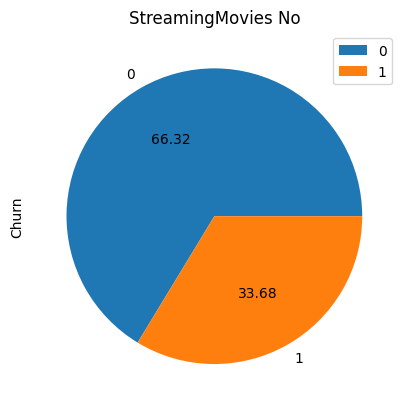

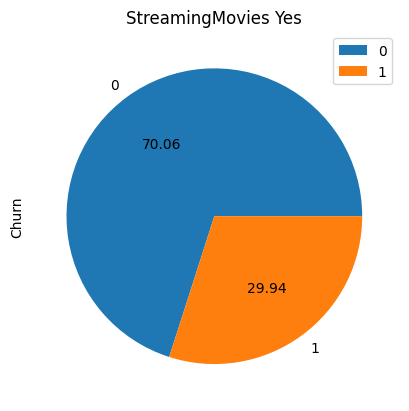

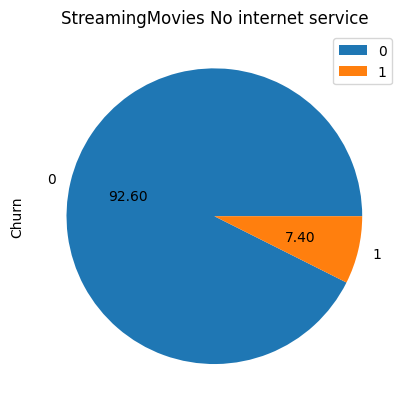

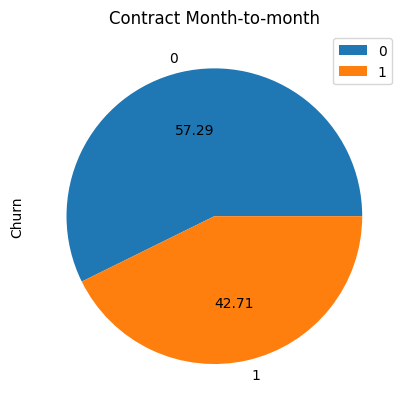

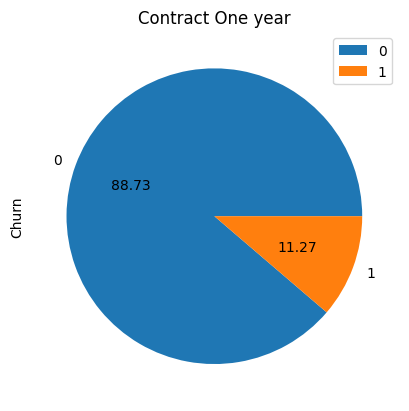

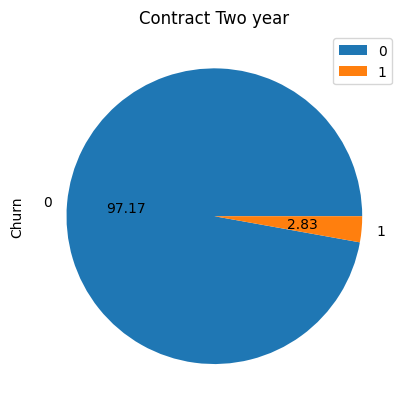

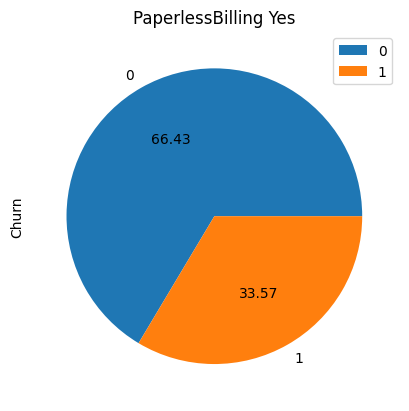

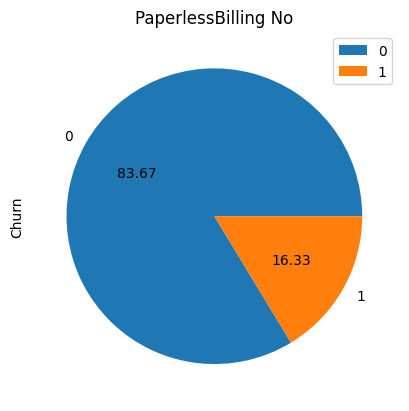

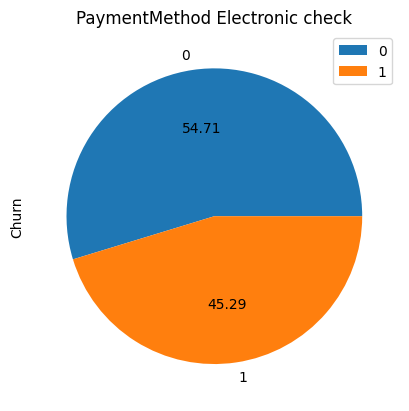

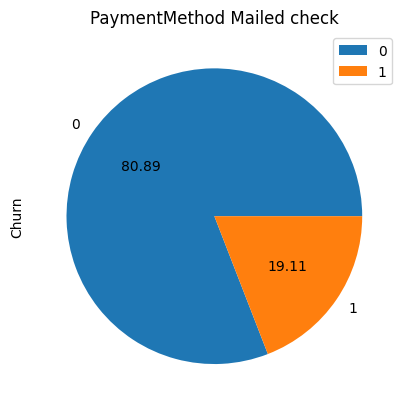

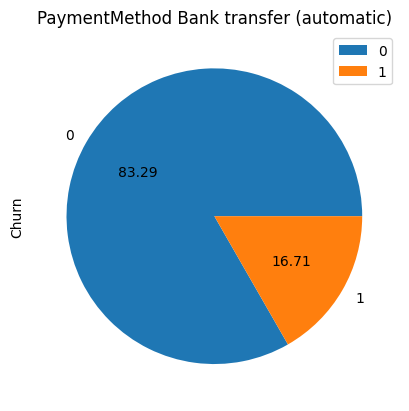

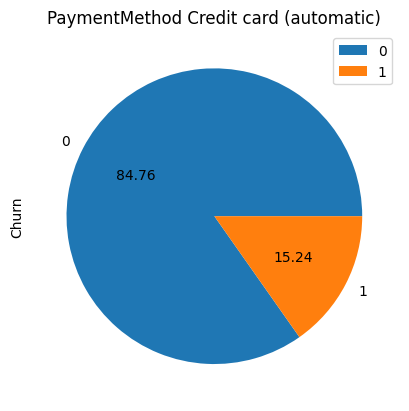

In [32]:

for col in telco_df.columns[:-1]:
  if telco_df[col].nunique() < 6:
    for i in telco_df[col].unique():

      churn_temp = telco_df[telco_df[col]==i].groupby('Churn').agg({'Churn':'count'})
      churn_temp.plot(kind="pie",y="Churn",autopct="%.2f")
      plt.title(f'{col} {i}')
      plt.show()


SeniorCitizen are churning significantlt more than the non Seniors

People with No partner have more chance of churning

People with No dependents have a higher chance to churn
compared to ones with dependents

Fiber optic user churn significantly more than the Users with DSL and No internet service
there might be a problem with Fiber Optic

Users with No online Security,no online backup ,no device protection and no tech support churn more than the users with these services

Users with month to month contract are more likely to churn than the users with one or two year contract

Users who do PaperLess billing are slightly more likely to churn

Users who pay using Electronic Check are heavily involved in churning

In [33]:
for col in telco_df.columns[:-1]:
  if telco_df[col].nunique() < 6:
    for i in telco_df[col].unique():

      churn_temp = telco_df[telco_df[col]==i].groupby('Churn').agg({'Churn':'count'})
      churn_temp = churn_temp/churn_temp.sum()
      if churn_temp[churn_temp.index == 1].values > 0.31:
        print(f'{col} - {i}  - {round(churn_temp[churn_temp.index == 1].values[0][0]*100)}% chance of churning')


SeniorCitizen - 1  - 42% chance of churning
Partner - No  - 33% chance of churning
Dependents - No  - 31% chance of churning
InternetService - Fiber optic  - 42% chance of churning
OnlineSecurity - No  - 42% chance of churning
OnlineBackup - No  - 40% chance of churning
DeviceProtection - No  - 39% chance of churning
TechSupport - No  - 42% chance of churning
StreamingTV - No  - 34% chance of churning
StreamingMovies - No  - 34% chance of churning
Contract - Month-to-month  - 43% chance of churning
PaperlessBilling - Yes  - 34% chance of churning
PaymentMethod - Electronic check  - 45% chance of churning


SeniorCitizen have 42% chance of churning

Users with No Partner have 33% chance of churning

Users with No Dependents have 31% chance of churning

Users with Fiber optic InternetService have 42% chance of churning

Users with No OnlineSecurity have 42% chance of churning

Users with No OnlineBackup have 40% chance of churning

Users with No DeviceProtection have 39% chance of churning

Users with No TechSupport have 42% chance of churning

Users with No StreamingTV have 34% chance of churning

Users with No StreamingMovies have 34% chance of churning

Users with Month-to-month Contract have 43% chance of churning

Users with PaperlessBilling have 34% chance of churning

Users who pay using Electronic check have 45% chance of churning




In [34]:
temp = telco_df[['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies']]
for col in temp.columns:
  temp[col] = temp[col].map({"Yes":1,"No":0,"No internet service":0})

In [35]:
new_temp = pd.DataFrame([temp.T.sum().T,telco_df.Churn]).T
new_temp.columns = ['Total_Services','Churn']
new_temp

,Total_Services,Churn
0,1,0
1,2,0
2,2,1
3,3,0
4,0,1
...,...,...
7038,5,0
7039,4,0
7040,1,0
7041,0,1


In [36]:
new_temp.groupby('Churn').agg({'Total_Services':'mean'})

,Total_Services
Churn,
0,2.135292
1,1.768325


In [37]:
serv_df = new_temp.groupby('Total_Services').agg({'Churn':'sum'})
serv_per = round(serv_df/serv_df.sum()*100,2)
serv_per

,Churn
Total_Services,
0,25.41
1,23.65
2,19.80
3,16.37
4,10.17
5,3.80
6,0.80


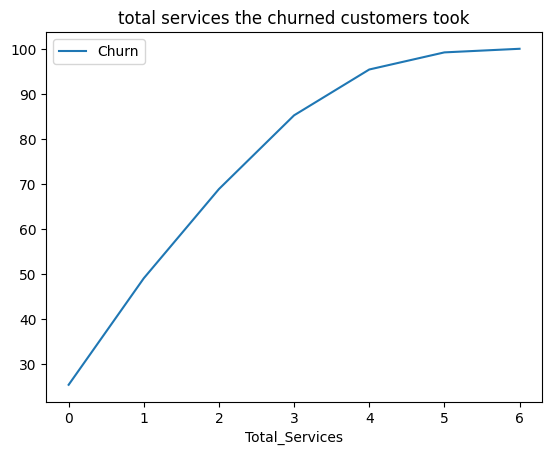

In [38]:
serv_per.cumsum().plot()
plt.title('total services the churned customers took')
plt.show()

86% of the churned customers had 3 or less services


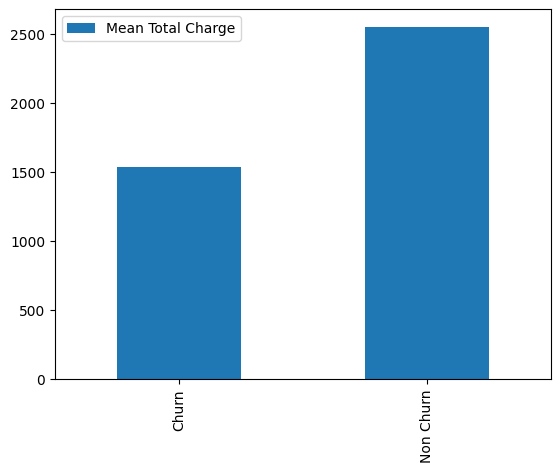

In [39]:
temp = pd.DataFrame([churn_df.TotalCharges.mean(),non_churn_df.TotalCharges.mean()])
temp.index = ['Churn','Non Churn']
temp.columns = ['Mean Total Charge']
temp.plot(kind="bar")
plt.show()

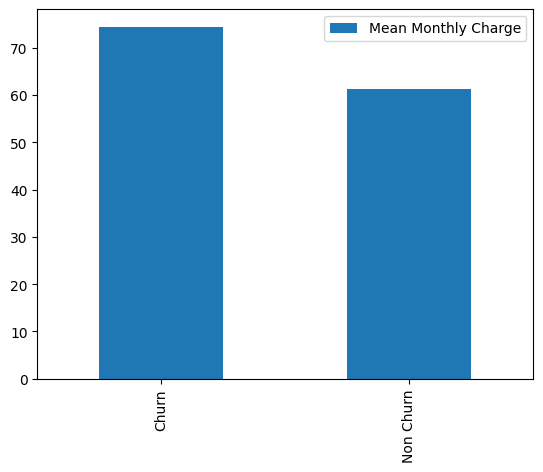

In [40]:
temp = pd.DataFrame([churn_df.MonthlyCharges.mean(),non_churn_df.MonthlyCharges.mean()])
temp.index = ['Churn','Non Churn']
temp.columns = ['Mean Monthly Charge']
temp.plot(kind="bar")
plt.show()

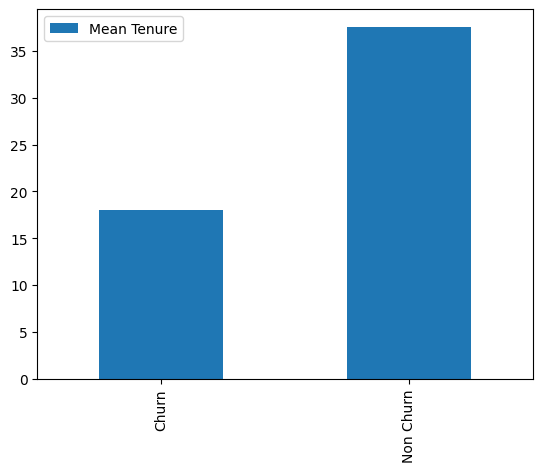

In [41]:
temp = pd.DataFrame([churn_df.tenure.mean(),non_churn_df.tenure.mean()])
temp.index = ['Churn','Non Churn']
temp.columns = ['Mean Tenure']
temp.plot(kind="bar")
plt.show()

people with less monthly charges but higher Total charges with longer tenure tend to stay
which means people who are applying for the yearly contracts will not churn


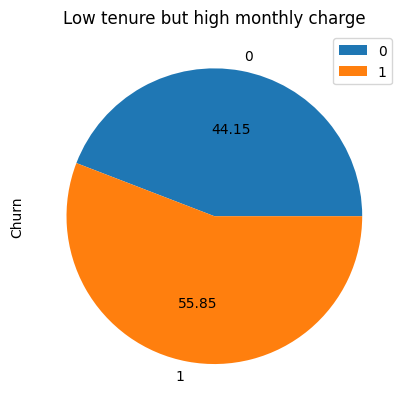

In [42]:
temp = telco_df[
(telco_df.tenure < telco_df.tenure.mean())
& (telco_df.MonthlyCharges > telco_df.MonthlyCharges.mean())
& (telco_df.TotalCharges < telco_df.TotalCharges.mean())
].groupby('Churn').agg({'Churn':'count'})
temp.plot(kind="pie",y="Churn",autopct="%.2f")
plt.title("Low tenure but high monthly charge")
plt.show()

Machine learning


In [66]:
object_col = telco_df.select_dtypes('object').columns[1:]
object_col

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [76]:
number_col = list(set(telco_df.columns) - set(object_col))
number_col

['MonthlyCharges',
 'customerID',
 'Churn',
 'tenure',
 'TotalCharges',
 'SeniorCitizen']

In [77]:
len(number_col)+len(object_col)

21

In [78]:
telco_df.shape

(7043, 21)

In [79]:
for col in telco_df[object_col]:
  print(col)
  print(telco_df[col].value_counts(),"\n")

gender
gender
Male      3555
Female    3488
Name: count, dtype: int64 

Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64 

Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64 

PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64 

MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64 

InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64 

OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64 

OnlineBackup
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64 

DeviceProtection
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64 

TechSupport
TechSupport
No     

In [80]:
telco_df[object_col]

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check
1,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check
2,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check
3,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic)
4,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check
7039,Female,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic)
7040,Female,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check
7041,Male,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check


In [85]:
dummy_encode = pd.get_dummies(telco_df[object_col], drop_first=True).astype(int)
dummy_encode

,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
1,1,0,0,1,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
2,1,0,0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,1
3,1,0,0,0,1,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,0,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,1,1,1,0,1,0,0,0,1,...,0,1,0,1,1,0,1,0,0,1
7039,0,1,1,1,0,1,1,0,0,0,...,0,1,0,1,1,0,1,1,0,0
7040,0,1,1,0,1,0,0,0,0,1,...,0,0,0,0,0,0,1,0,1,0
7041,1,1,0,1,0,1,1,0,0,0,...,0,0,0,0,0,0,1,0,0,1


In [166]:
ml_telco = pd.concat([telco_df[number_col],dummy_encode],axis=1)
ml_telco

,MonthlyCharges,customerID,Churn,tenure,TotalCharges,SeniorCitizen,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,29.85,7590-VHVEG,0,1,29.85,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0
1,56.95,5575-GNVDE,0,34,1889.50,0,1,0,0,1,...,0,0,0,0,1,0,0,0,0,1
2,53.85,3668-QPYBK,1,2,108.15,0,1,0,0,1,...,0,0,0,0,0,0,1,0,0,1
3,42.30,7795-CFOCW,0,45,1840.75,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,70.70,9237-HQITU,1,2,151.65,0,0,0,0,1,...,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,84.80,6840-RESVB,0,24,1990.50,0,1,1,1,1,...,0,1,0,1,1,0,1,0,0,1
7039,103.20,2234-XADUH,0,72,7362.90,0,0,1,1,1,...,0,1,0,1,1,0,1,1,0,0
7040,29.60,4801-JZAZL,0,11,346.45,0,0,1,1,0,...,0,0,0,0,0,0,1,0,1,0
7041,74.40,8361-LTMKD,1,4,306.60,1,1,1,0,1,...,0,0,0,0,0,0,1,0,0,1


In [167]:
ml_telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   MonthlyCharges                         7043 non-null   float64
 1   customerID                             7043 non-null   object 
 2   Churn                                  7043 non-null   int64  
 3   tenure                                 7043 non-null   int64  
 4   TotalCharges                           7043 non-null   float64
 5   SeniorCitizen                          7043 non-null   int64  
 6   gender_Male                            7043 non-null   int64  
 7   Partner_Yes                            7043 non-null   int64  
 8   Dependents_Yes                         7043 non-null   int64  
 9   PhoneService_Yes                       7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  Mult

In [168]:
for col in ml_telco.columns:
  new_col = col.lower().replace(" ","_")
  ml_telco.rename(columns={col:new_col},inplace=True)
ml_telco.columns

Index(['monthlycharges', 'customerid', 'churn', 'tenure', 'totalcharges',
       'seniorcitizen', 'gender_male', 'partner_yes', 'dependents_yes',
       'phoneservice_yes', 'multiplelines_no_phone_service',
       'multiplelines_yes', 'internetservice_fiber_optic',
       'internetservice_no', 'onlinesecurity_no_internet_service',
       'onlinesecurity_yes', 'onlinebackup_no_internet_service',
       'onlinebackup_yes', 'deviceprotection_no_internet_service',
       'deviceprotection_yes', 'techsupport_no_internet_service',
       'techsupport_yes', 'streamingtv_no_internet_service', 'streamingtv_yes',
       'streamingmovies_no_internet_service', 'streamingmovies_yes',
       'contract_one_year', 'contract_two_year', 'paperlessbilling_yes',
       'paymentmethod_credit_card_(automatic)',
       'paymentmethod_electronic_check', 'paymentmethod_mailed_check'],
      dtype='object')

In [172]:
ml_telco.drop(columns='customerid',inplace=True)

In [173]:
y = ml_telco["churn"]
X = ml_telco.drop("churn",axis=1)
X.shape, y.shape

((7043, 30), (7043,))

In [174]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [175]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train),columns=X_train.columns,index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test),columns=X_test.columns,index=X_test.index)


In [176]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(logreg.score(X_test, y_test)))
print(metrics.classification_report(y_test, y_pred))

Accuracy of logistic regression classifier on test set: 0.82
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1697
           1       0.69      0.59      0.63       628

    accuracy                           0.82      2325
   macro avg       0.77      0.75      0.76      2325
weighted avg       0.81      0.82      0.81      2325



In [177]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)
print('Accuracy of Decision Tree classifier on test set: {:.2f}'.format(tree.score(X_test, y_test)))
print(metrics.classification_report(y_test, y_pred))

Accuracy of Decision Tree classifier on test set: 0.73
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1697
           1       0.50      0.52      0.51       628

    accuracy                           0.73      2325
   macro avg       0.66      0.66      0.66      2325
weighted avg       0.73      0.73      0.73      2325



In [178]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [179]:
logreg_smote = LogisticRegression()
logreg_smote.fit(X_train_res, y_train_res)
y_pred = logreg.predict(X_test)
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(logreg.score(X_test, y_test)))
print(metrics.classification_report(y_test, y_pred))

Accuracy of logistic regression classifier on test set: 0.82
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1697
           1       0.69      0.59      0.63       628

    accuracy                           0.82      2325
   macro avg       0.77      0.75      0.76      2325
weighted avg       0.81      0.82      0.81      2325



In [180]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)
y_pred = rf.predict(X_test)
print('Accuracy of Random Forest classifier on test set: {:.2f}'.format(rf.score(X_test, y_test)))
print(metrics.classification_report(y_test, y_pred))

Accuracy of Random Forest classifier on test set: 0.79
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1697
           1       0.61      0.61      0.61       628

    accuracy                           0.79      2325
   macro avg       0.74      0.74      0.74      2325
weighted avg       0.79      0.79      0.79      2325



Lets use the logreg


In [181]:
pip install eli5

In [183]:
import eli5
from eli5.sklearn import PermutationImportance

perm = PermutationImportance(logreg, random_state=1).fit(X_test, y_test)
eli5.show_weights(perm, feature_names=X_test.columns.tolist())


Weight,Feature
0.1160 ± 0.0099,tenure
0.0657 ± 0.0117,internetservice_fiber_optic
0.0348 ± 0.0078,monthlycharges
0.0255 ± 0.0108,totalcharges
0.0186 ± 0.0096,contract_two_year
0.0109 ± 0.0023,streamingmovies_yes
0.0084 ± 0.0042,paperlessbilling_yes
0.0076 ± 0.0051,streamingtv_yes
0.0074 ± 0.0074,multiplelines_yes
0.0055 ± 0.0060,contract_one_year


In [184]:
weights_df = eli5.explain_weights_df(perm, feature_names=X_test.columns.tolist())
top_features = weights_df[weights_df["weight"]>0.002].feature.to_list()
top_features

['tenure',
 'internetservice_fiber_optic',
 'monthlycharges',
 'totalcharges',
 'contract_two_year',
 'streamingmovies_yes',
 'paperlessbilling_yes',
 'streamingtv_yes',
 'multiplelines_yes',
 'contract_one_year',
 'paymentmethod_electronic_check',
 'onlinebackup_yes',
 'onlinesecurity_yes',
 'deviceprotection_yes',
 'streamingtv_no_internet_service',
 'deviceprotection_no_internet_service']

In [189]:
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]
logreg_3 = LogisticRegression()
logreg_3.fit(X_train_top, y_train)
y_pred = logreg_3.predict(X_test_top)
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(logreg_3.score(X_test_top, y_test)))
print(metrics.classification_report(y_test, y_pred))

Accuracy of logistic regression classifier on test set: 0.82
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1697
           1       0.69      0.59      0.63       628

    accuracy                           0.82      2325
   macro avg       0.77      0.75      0.76      2325
weighted avg       0.81      0.82      0.81      2325



In [191]:
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X[top_features], y, test_size=0.33, random_state=42)

In [192]:
logreg_new = LogisticRegression()
logreg_new.fit(X_train_new, y_train_new)
y_pred = logreg_new.predict(X_test_new)
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(logreg_new.score(X_test_new, y_test_new)))
print(metrics.classification_report(y_test_new, y_pred))

Accuracy of logistic regression classifier on test set: 0.81
              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1697
           1       0.68      0.56      0.62       628

    accuracy                           0.81      2325
   macro avg       0.77      0.73      0.75      2325
weighted avg       0.80      0.81      0.81      2325



lets finalize logred_3 as the final model

In [194]:
perm_final = PermutationImportance(logreg_3, random_state=1).fit(X_test_top, y_test)
weights_df = eli5.explain_weights_df(perm_final, feature_names=X_test_top.columns.tolist())
weights_df

,feature,weight,std
0,tenure,0.117591,0.009239
1,internetservice_fiber_optic,0.081548,0.007859
2,monthlycharges,0.068043,0.006170
3,totalcharges,0.030796,0.003574
4,contract_two_year,0.018581,0.003291
5,streamingmovies_yes,0.012903,0.003895
6,streamingtv_yes,0.012731,0.002381
7,multiplelines_yes,0.009892,0.002402
8,paperlessbilling_yes,0.009376,0.003572
9,contract_one_year,0.009118,0.004330


### Top Drivers of Churn:

* tenure: Longer-tenure customers are less likely to churn.

* internet service fiber optic: Customers with fiber optic internet are more likely to churn.

* monthly charges: Higher monthly charges increase churn risk.

* total charges: Lower total charges slightly increase churn likelihood.


### Moderately Influential Factors:

* people with contract of two year, who are streaming movies and tv: Influence churn but less strongly.

* paperless billing : Small positive effect on churn.


### Low-Impact or Negligible Features:

* online security, online backup: Very low or negative importance; can be considered for removal.

* Features with weight < 0.002 have minimal impact on predictions and hence are removed form the model

### Actionable Insights for Business:

* Focus retention strategies on high-billing and fiber-optic users.

* Incentivize longer-term contracts (especially 2-year) to reduce churn.

In [199]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(logreg_3, f)

In [200]:
with open("model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

In [201]:
loaded_model.predict(X_test_top)

array([1, 0, 0, ..., 1, 1, 0])

In [224]:
temp = scaler.fit_transform(ml_telco[top_features])
proba = list(logreg_3.predict_proba(temp)[:,1])

In [227]:
telco_df["churn_prob"] = proba
telco_df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,churn_prob
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0.621361
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,0.041117
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0.268027
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,0.037998
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0.675006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0,0.143772
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0,0.169674
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0,0.453599
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1,0.646816


In [230]:
def get_segment(row):
    if row['churn_prob'] >= 0.6:
        return "At Risk"
    elif row['tenure'] > 24 and row['churn_prob'] < 0.3:
        return "Loyal"
    elif row['tenure'] < 6 and row['churn_prob'] < 0.5:
        return "Dormant"
    else:
        return "Standard"

telco_df['segment'] = telco_df.apply(get_segment, axis=1)

In [231]:
telco_df.segment.value_counts()

,count
segment,
Loyal,3164
Standard,2261
At Risk,935
Dormant,683


In [232]:
telco_df.to_csv("final_telco.csv")